# Parameter Inference

The availability of exact moments lends itself to gradient-based parameter inference.

In [1]:
Sys.setenv(TQDM_DISABLE = "1")
setwd("~/PycharmProjects/PhaseGen/")
reticulate::use_condaenv("/Users/janek/miniforge3/envs/dev-phasegen", required = TRUE)

In [2]:
mpl <- reticulate::import("matplotlib")
mpl$use("Agg")
plt <- reticulate::import("matplotlib.pyplot")
plt$rcParams[["figure.figsize"]] <- c(4.4, 3.3)
options(repr.plot.width = 4.4, repr.plot.height = 3.3)

# render a phasegen plot object (calls its .plot()) inline
render <- function(obj) {
  p <- tempfile(fileext = ".png"); obj$plot(show = FALSE, file = p); IRdisplay::display_png(file = p)
}
# render an arbitrary matplotlib figure drawn by `draw`, which saves to the given path
render_fn <- function(draw) {
  p <- tempfile(fileext = ".png"); draw(p); IRdisplay::display_png(file = p)
}
# run a call and echo the phasegen log output it emits, so it is captured in the rendered cell
with_log <- function(expr) cat(reticulate::py_capture_output(expr))

In [3]:
library(phasegen)

pg <- load_phasegen()

## Running an inference

We infer the parameters of a two-epoch demography from an observed SFS.

In [23]:
observation <- pg$SFS(
    c(177130, 997, 441, 228, 156, 117, 114, 83, 105, 109, 652)
)

inf <- pg$Inference(
    bounds = list(t = c(0, 4), Ne = c(0.1, 1)),
    observation = observation,
    coal = function(t, Ne) pg$Coalescent(
        n = 10,
        demography = pg$Demography(
            pop_sizes = list(pop_0 = reticulate::py_dict(list(0, t), list(1, Ne)))
        )
    ),
    loss = function(coal, observation) pg$PoissonLikelihood()$compute(
        observed = observation$normalize()$polymorphic,
        modelled = coal$sfs$mean$normalize()$polymorphic
    )
)

Upon construction, the inference object is ready to be optimized; the inferred demography can then be visualized.

In [24]:
with_log(inf$run())

INFO:Inference: Inferred parameters: (t=0.1455, Ne=0.4814)


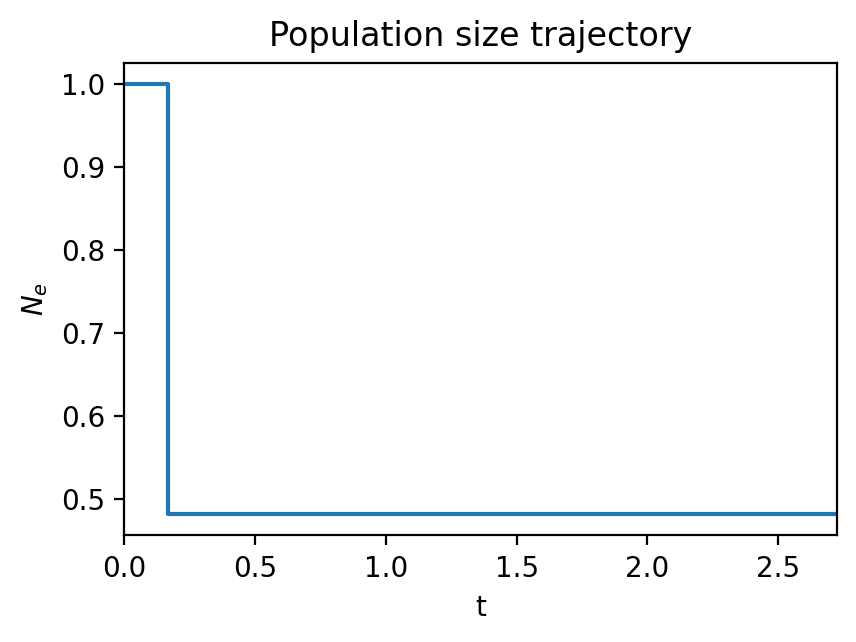

In [25]:
render_fn(function(f) inf$plot_pop_sizes(show = FALSE, file = f))

## Parametric bootstrapping

We may also perform parametric bootstrapping by providing a `resample` callback, then inspect the bootstrap distribution of the inferred parameters.

In [26]:
inf <- pg$Inference(
    bounds = list(t = c(0, 4), Ne = c(0.1, 1)),
    observation = observation,
    do_bootstrap = TRUE,
    n_bootstraps = 20L,
    coal = function(t, Ne) pg$Coalescent(
        n = 10,
        demography = pg$Demography(
            pop_sizes = list(pop_0 = reticulate::py_dict(list(0, t), list(1, Ne)))
        )
    ),
    loss = function(coal, observation) pg$PoissonLikelihood()$compute(
        observed = observation$normalize()$polymorphic,
        modelled = coal$sfs$mean$normalize()$polymorphic
    ),
    resample = function(sfs, rng) sfs$resample(seed = as.integer(rng$integers(1e9)))
)

In [27]:
with_log(inf$run())

INFO:Inference: Inferred parameters: (t=0.1455, Ne=0.4814)
INFO:Inference: Bootstrapped parameters: mean: (t=0.1398, Ne=0.4566), std: (t=0.0290, Ne=0.0399)


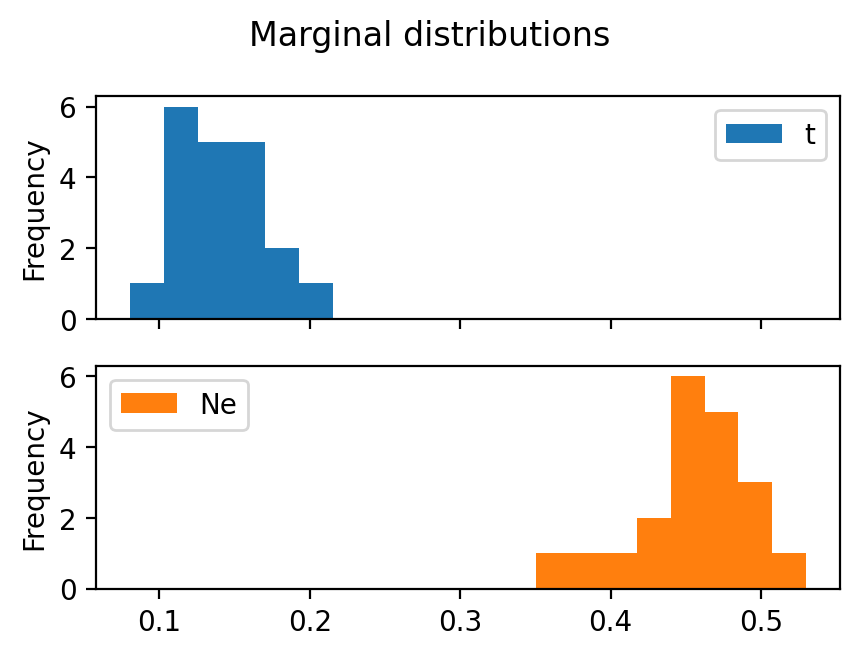

In [28]:
render_fn(function(f) inf$plot_bootstraps(show = FALSE, file = f))

## Distributed bootstrapping
Whenever running inference with long runtimes, you might want to distribute the bootstrapping process. This can be done by creating bootstrap samples which are {class}`~phasegen.inference.Inference` objects themselves ({meth}`~phasegen.inference.Inference.create_bootstrap`). These bootstraps can be run in parallel and the results combined afterwards ({meth}`~phasegen.inference.Inference.add_bootstraps`).

In a production setting the bootstraps are typically farmed out across a cluster, for instance with a [Snakemake](https://snakemake.readthedocs.io/en/stable/) workflow: one rule sets up the inference and performs the initial run ({meth}`~phasegen.inference.Inference.to_file`), a second rule loads it ({meth}`~phasegen.inference.Inference.from_file`), creates a single bootstrap and runs it, and a final rule merges the bootstrap results back into the main inference object. Below we demonstrate the same API in a single notebook, running the bootstraps in a serial loop rather than as parallel cluster jobs.

Two points are specific to driving `phasegen` from R. First, `create_bootstrap` and `to_file` serialize the `coal`, `loss` and `resample` callbacks, so we define them as Python functions (via `reticulate::py_run_string`) rather than R closures, which do not survive that round-trip. Second, we accumulate the bootstrap objects in memory and merge them directly, rather than reloading each from its file, so their optimizer results stay intact.

In [4]:
# the model, loss and resampling callbacks, defined in Python so they survive serialization
py <- reticulate::py_run_string('
import phasegen as pg

def coal(t, Ne):
    return pg.Coalescent(
        n=10,
        demography=pg.Demography(pop_sizes={"pop_0": {0: 1, t: Ne}}),
    )

def loss(coal, obs):
    return pg.PoissonLikelihood().compute(
        observed=obs.normalize().polymorphic,
        modelled=coal.sfs.mean.normalize().polymorphic,
    )

def resample(sfs, rng):
    return sfs.resample(seed=int(rng.integers(1_000_000_000)))
')

We set up the inference object, perform the initial run and save the result to a file. Bootstrapping is disabled here as we perform it manually.

In [5]:
inf <- pg$Inference(
    bounds = list(t = c(0, 4), Ne = c(0.1, 1)),
    observation = pg$SFS(c(177130, 997, 441, 228, 156, 117, 114, 83, 105, 109, 652)),
    coal = py$coal,
    loss = py$loss,
    resample = py$resample,
    do_bootstrap = FALSE
)

with_log(inf$run())

dir.create("results/inference", recursive = TRUE, showWarnings = FALSE)
inf$to_file("results/inference/inference.json")

INFO:Inference: Inferred parameters: (t=0.1455, Ne=0.4814)


Each bootstrap is created from the inference object with {meth}`~phasegen.inference.Inference.create_bootstrap`, which resamples the observation using the provided `resample` callback, and is then run independently. On a cluster each iteration of this loop would instead be a separate job that loads ``inference.json``, creates one bootstrap, runs it and writes its own file. Here we reload the saved object once and run the replicates serially.

In [6]:
inf <- pg$Inference$from_file("results/inference/inference.json")

boots <- NULL
with_log(boots <<- lapply(seq_len(20L), function(i) {
    b <- inf$create_bootstrap()
    b$run()
    b
}))

INFO:Inference: Inferred parameters: (t=0.1645, Ne=0.5149)
INFO:Inference: Inferred parameters: (t=0.1919, Ne=0.4703)
INFO:Inference: Inferred parameters: (t=0.1759, Ne=0.5760)
INFO:Inference: Inferred parameters: (t=0.4705, Ne=0.6171)
INFO:Inference: Inferred parameters: (t=0.1246, Ne=0.3923)
INFO:Inference: Inferred parameters: (t=0.1536, Ne=0.4454)
INFO:Inference: Inferred parameters: (t=0.7016, Ne=0.7181)
INFO:Inference: Inferred parameters: (t=0.1258, Ne=0.5390)
INFO:Inference: Inferred parameters: (t=0.1421, Ne=0.4750)
INFO:Inference: Inferred parameters: (t=0.1473, Ne=0.4467)
INFO:Inference: Inferred parameters: (t=0.1372, Ne=0.5087)
INFO:Inference: Inferred parameters: (t=0.1457, Ne=0.4302)
INFO:Inference: Inferred parameters: (t=0.2092, Ne=0.5843)
INFO:Inference: Inferred parameters: (t=0.1902, Ne=0.5223)
INFO:Inference: Inferred parameters: (t=0.0955, Ne=0.4098)
INFO:Inference: Inferred parameters: (t=0.7578, Ne=0.7248)
INFO:Inference: Inferred parameters: (t=0.1761, Ne=0.490

Finally we merge the bootstraps into the main inference object with {meth}`~phasegen.inference.Inference.add_bootstraps` and visualize the inferred demography and the bootstrap distribution of the inferred parameters.

In [7]:
inf$add_bootstraps(boots)

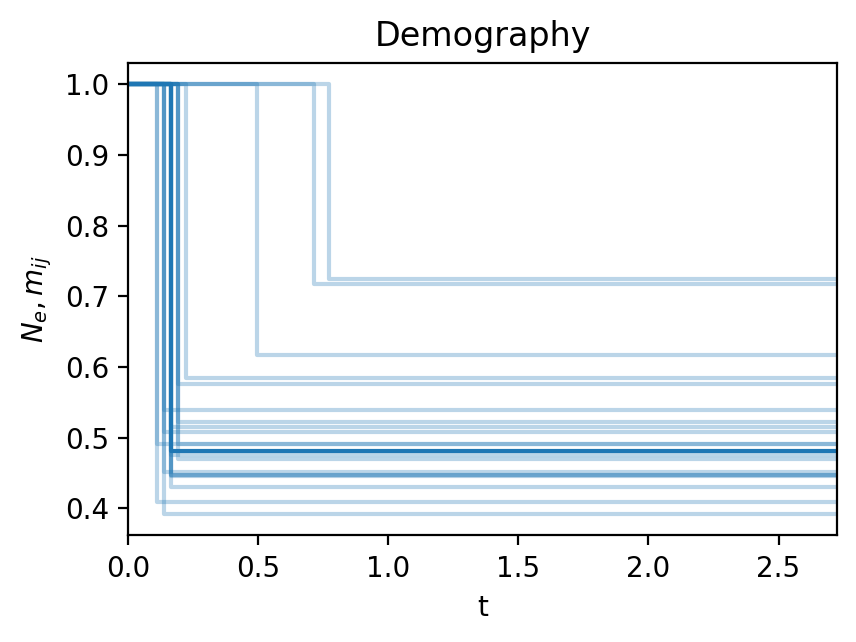

In [8]:
render_fn(function(f) inf$plot_demography(show = FALSE, file = f))

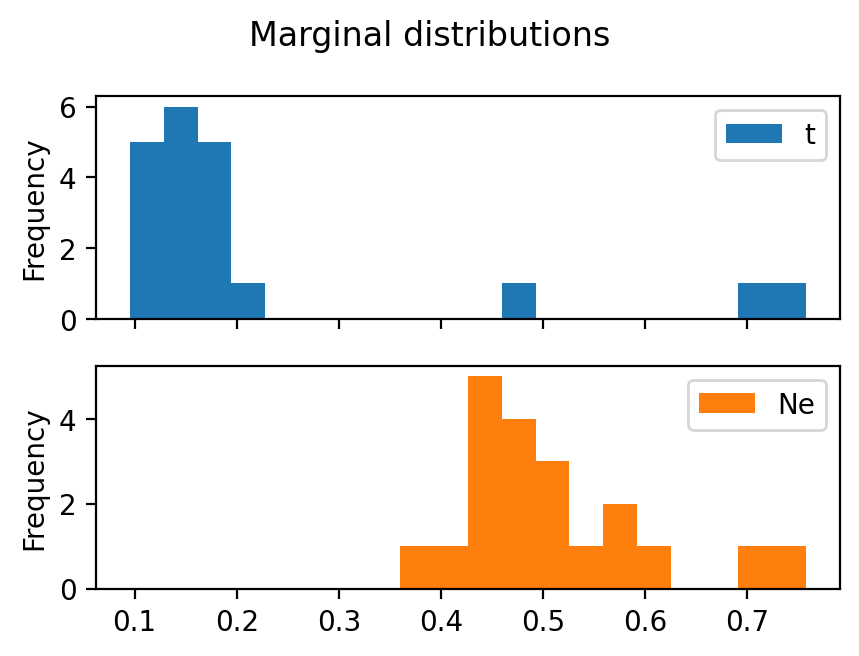

In [9]:
render_fn(function(f) inf$plot_bootstraps(show = FALSE, file = f))